In [4]:
import pandas as pd

# Load the CSV from root
df = pd.read_csv('/DMart_sample_data.csv')

# Print summary
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

# View the first 5 records
df.head()

Number of rows and columns: (1000000, 8)

Column names:
['Date', 'Time', 'CustomerType', 'ProductCategory', 'UnitPrice', 'Quantity', 'Total', 'FullName']


,Date,Time,CustomerType,ProductCategory,UnitPrice,Quantity,Total,FullName
0,31-12-2023 15:41,06:04:28,Member,Grocery,10.69,4,42.76,Jai Bhatia
1,07-01-2024 22:19,01:05:18,Premium,Home & Kitchen,381.03,3,1143.09,Ishaan Patel
2,10-01-2024 02:09,17:31:43,Regular,Grocery,153.84,5,769.20,Tanvi Iyer
3,01-06-2023 10:46,01:50:16,Regular,Electronics,341.41,4,1365.64,Zara Xavier
4,23-05-2024 22:07,10:37:06,Regular,Home & Kitchen,390.16,5,1950.80,Krishna Zutshi


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Clean the date column
# Extract just the date part (DD-MM-YYYY) and convert to datetime
df['CleanDate'] = pd.to_datetime(df['Date'].str.split(' ').str[0], format='%d-%m-%Y', errors='coerce')

# Drop any rows with invalid dates
df = df.dropna(subset=['CleanDate'])

# 2. Aggregate transactions into daily total sales
daily_sales = df.groupby('CleanDate').agg({
    'Total': 'sum',
    'Quantity': 'sum'
}).reset_index().rename(columns={'CleanDate': 'Date', 'Total': 'DailySales', 'Quantity': 'TotalUnits'})

# Sort chronologically
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

# 3. Create Time Features (Feature Engineering)
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['IsWeekend'] = daily_sales['DayOfWeek'].isin([5, 6]).astype(int)

# 4. Create Lag Features (Sales from previous days)
daily_sales['Sales_Lag1'] = daily_sales['DailySales'].shift(1)
daily_sales['Sales_Lag7'] = daily_sales['DailySales'].shift(7)

# Drop rows with NaN caused by shifting
daily_sales = daily_sales.dropna().reset_index(drop=True)

print("Total daily records prepared:", len(daily_sales))
daily_sales.head()

Total daily records prepared: 733


,Date,DailySales,TotalUnits,Day,Month,Year,DayOfWeek,IsWeekend,Sales_Lag1,Sales_Lag7
0,2023-01-08,1068412.71,4078,8,1,2023,6,1,1008752.38,1072285.28
1,2023-01-09,1074592.03,4081,9,1,2023,0,0,1068412.71,1035154.27
2,2023-01-10,1007321.03,3966,10,1,2023,1,0,1074592.03,1023660.67
3,2023-01-11,1038285.73,4231,11,1,2023,2,0,1007321.03,1105918.82
4,2023-01-12,1031215.78,4078,12,1,2023,3,0,1038285.73,1038459.50


Mean Absolute Error (MAE): 15106.04
Root Mean Squared Error (RMSE): 18637.33
R² Score: 0.7613


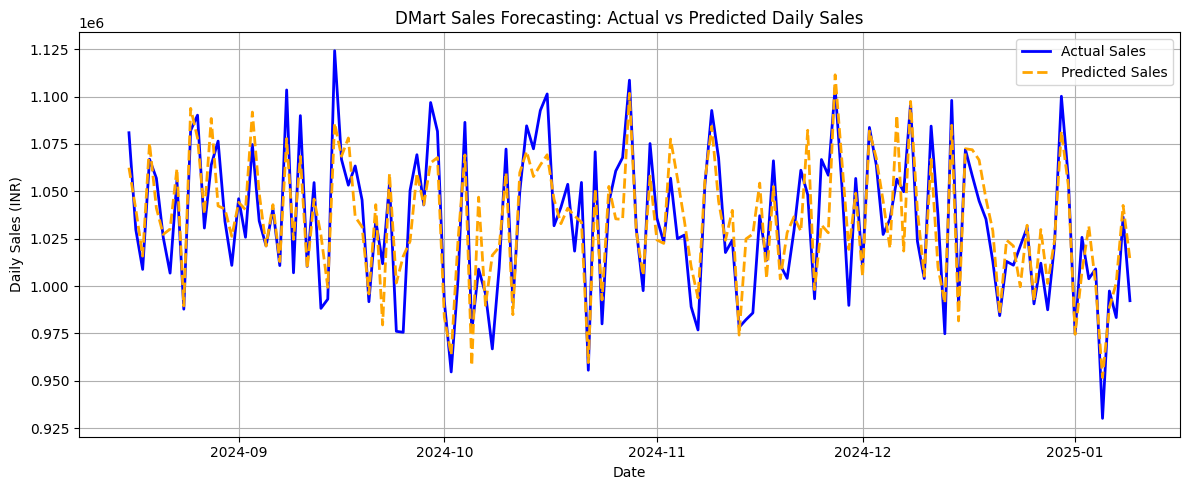

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
features = ['Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend', 'Sales_Lag1', 'Sales_Lag7', 'TotalUnits']
X = daily_sales[features]
y = daily_sales['DailySales']

# Chronological split: 80% training data, 20% testing data
split_idx = int(len(daily_sales) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot Actual vs Predicted Sales
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'].iloc[split_idx:], y_test.values, label='Actual Sales', color='blue', linewidth=2)
plt.plot(daily_sales['Date'].iloc[split_idx:], y_pred, label='Predicted Sales', color='orange', linestyle='--', linewidth=2)
plt.title('DMart Sales Forecasting: Actual vs Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Daily Sales (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()